In [60]:
import requests
import pandas as pd
from tqdm import tqdm
import tmdbdata as td
import genderprediction as gp 
import numpy as np
import matplotlib.pyplot as plt
import random
import ast

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score


# I - Chargement et traitement des données de l'API de TMDB

La première étape consiste à charger les données de TMDB grâce à leur API

In [28]:
#ids= td.get_movie_ids_list(20, headers=td.headers)
#liste=random.sample(range(1, 1000000), 4000)
#df=td.get_movies_info(liste,headers=td.headers)
#df.head(5)

In [29]:
df=pd.read_csv("data.csv")

df.head(3)

,success,status_code,status_message,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,...,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path
0,NaN,NaN,NaN,False,/CX6xcXLU90oGBz0mOxG3eHnZmD.jpg,NaN,0.0,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",NaN,47866.0,...,Released,"When Shade's good, she's very good. But when T...",Gas Food Lodging,False,6.3,58.0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,False,/sPEqnEZxaA0mPpgRx2E0kaCuRKe.jpg,NaN,0.0,"[{'id': 99, 'name': 'Documentary'}, {'id': 104...",NaN,450570.0,...,Released,NaN,J. Cole: 4 Your Eyez Only,False,9.0,3.0,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,True,NaN,NaN,0.0,[],NaN,483693.0,...,Released,NaN,Filthy First Timers 20,False,0.0,0.0,NaN,NaN,NaN,NaN


Telles quelles les données sont nombreuses et pas toutes nécessaires. Pour la lisibilité on élimine certaines colones, et traite certaines données. Par ailleurs, on construit de variables "overview_count" et "title_count" qui comptent le nombre de caractère de "overview" et de "title".

In [30]:
df1=td.clean_data(df)
df1.head(3)

,budget,id,overview,popularity,release_date,revenue,runtime,title,vote_average,vote_count,main_genre_id,main_genre_name,full_poster_path,overview_count,title_count,timestamp
0,0.0,47866.0,"Nora, a single mother raising two teenage daug...",6.726,1992-07-10,1345236.0,101.0,Gas Food Lodging,6.3,58.0,18,Drama,https://image.tmdb.org/t/p/original//pGuoFldLE...,393,16,710726400
1,0.0,450570.0,This documentary follows rapper J. Cole's 2016...,0.841,2017-04-15,0.0,49.0,J. Cole: 4 Your Eyez Only,9.0,3.0,99,Documentary,https://image.tmdb.org/t/p/original//5Ms6fSNkj...,338,25,1492214400
6,0.0,619079.0,"A singer and dancer par excellence, Lata lives...",1.043,1951-10-26,0.0,170.0,Bahar,0.0,0.0,18,Drama,https://image.tmdb.org/t/p/original//4sUEZUqoo...,565,5,-573868800


# II - Analyse descriptive des données

# III - Prédiction des notes et du genre d'un film

## B - Prédire le genre grâce à des Forêts Aléatoires

On s'intéresse maintenant au genre d'un film, et on cherche à le prédire grâce à nos données. On va utiliser pour cela un modèle classique de Machine Learning: les forêts aléatoires. 

In [31]:
X=df1.drop(columns=['id','overview','release_date', 'title', 'main_genre_name', "full_poster_path", "main_genre_id"])
y=df1['main_genre_id']

rf_num_full=gp.rfnum(X,y, random_state=1)

Rapport de classification :
              precision    recall  f1-score   support

          12       0.00      0.00      0.00        10
          14       0.00      0.00      0.00         7
          16       0.35      0.28      0.31        29
          18       0.37      0.61      0.46       100
          27       0.00      0.00      0.00        16
          28       0.00      0.00      0.00        19
          35       0.20      0.21      0.20        61
          36       0.00      0.00      0.00         1
          37       0.00      0.00      0.00         4
          53       0.00      0.00      0.00         6
          80       0.00      0.00      0.00         6
          99       0.48      0.65      0.55        81
         878       0.00      0.00      0.00         5
        9648       0.00      0.00      0.00         3
       10402       0.00      0.00      0.00        17
       10749       0.00      0.00      0.00         6
       10751       0.00      0.00      0.00         3

/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
df1cda=df1[df1['main_genre_id'].isin([28,18, 35])]

X=df1cda.drop(columns=['id','overview','release_date', 'title', 'main_genre_name', "full_poster_path", "main_genre_id"])
y=df1cda['main_genre_id']

rf_num_cda=gp.rfnum(X,y, random_state=1)

Rapport de classification :
              precision    recall  f1-score   support

          18       0.57      0.81      0.67        86
          28       0.00      0.00      0.00        21
          35       0.52      0.39      0.45        64

    accuracy                           0.56       171
   macro avg       0.36      0.40      0.37       171
weighted avg       0.48      0.56      0.50       171

timestamp         0.167538
runtime           0.164455
popularity        0.160035
overview_count    0.152523
title_count       0.145918
vote_average      0.099136
vote_count        0.085724
budget            0.013912
revenue           0.010759
dtype: float64


/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Rapport de classification :
                 precision    recall  f1-score   support

         Action       0.00      0.00      0.00        20
      Adventure       0.00      0.00      0.00         6
      Animation       0.38      0.21      0.27        28
         Comedy       0.37      0.48      0.42        61
          Crime       0.00      0.00      0.00         7
    Documentary       0.45      0.66      0.54        77
          Drama       0.45      0.69      0.55       102
         Family       0.00      0.00      0.00         2
        Fantasy       0.00      0.00      0.00         2
        History       0.00      0.00      0.00         3
         Horror       0.00      0.00      0.00        18
          Music       1.00      0.20      0.33        10
        Mystery       0.00      0.00      0.00         2
        Romance       1.00      0.06      0.11        18
Science Fiction       0.00      0.00      0.00         5
       TV Movie       0.00      0.00      0.00         5
 

/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


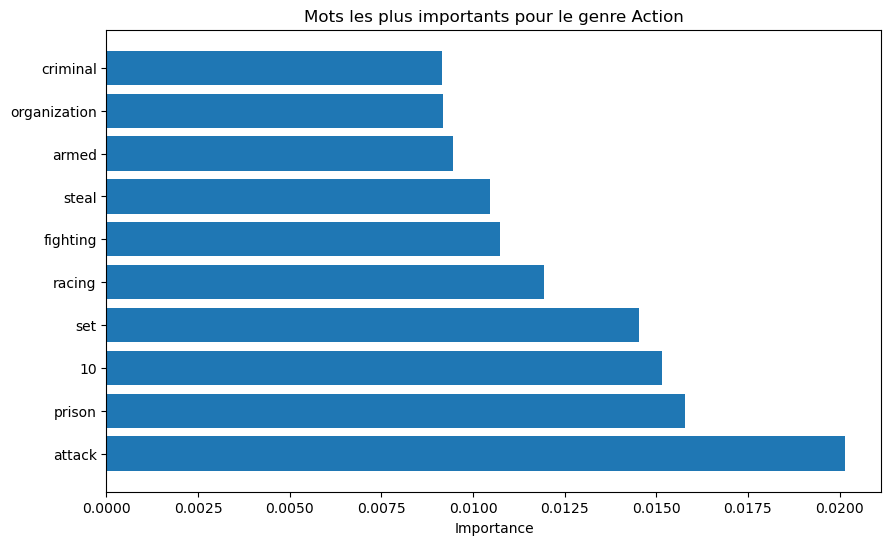

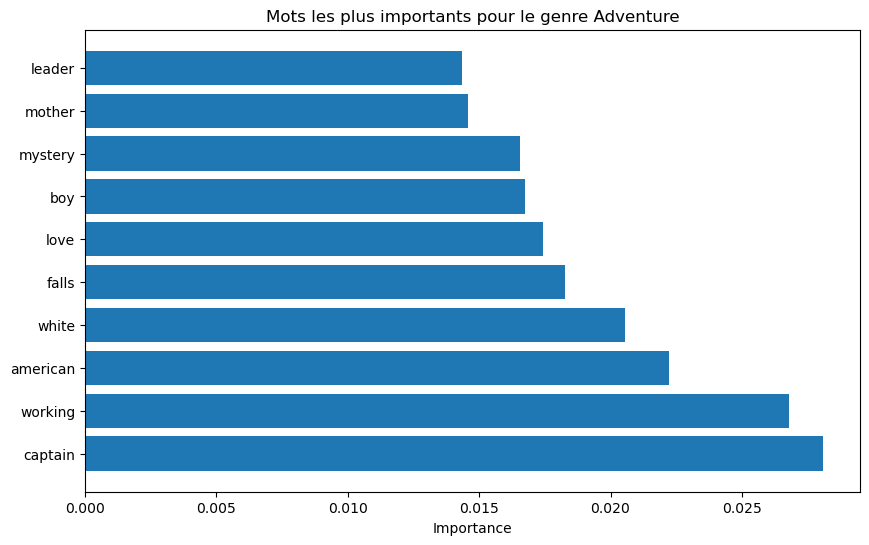

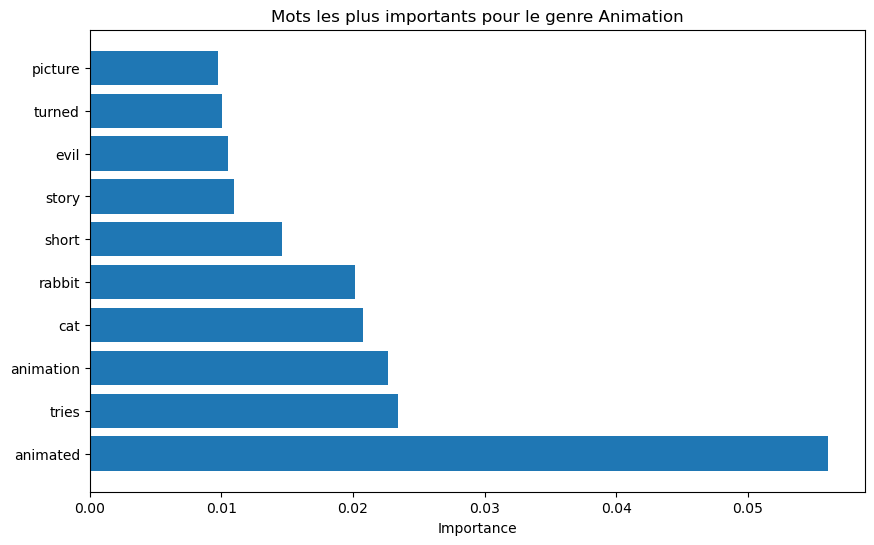

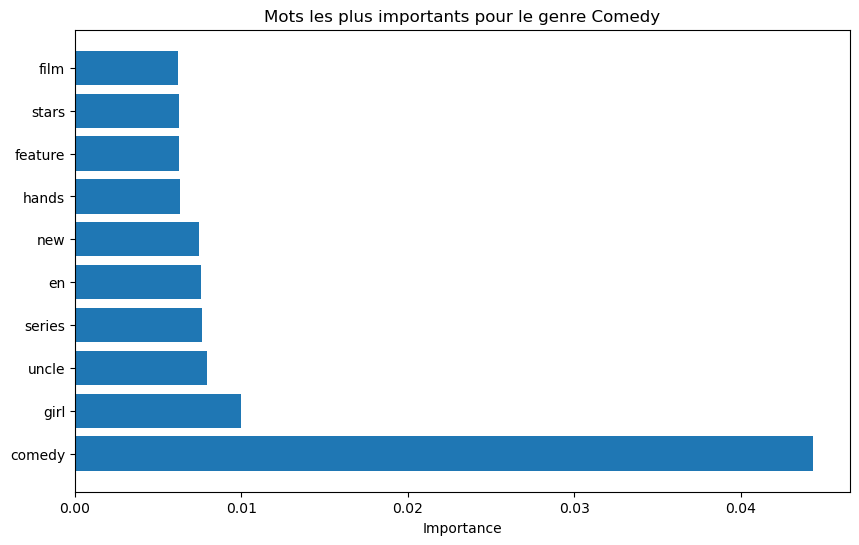

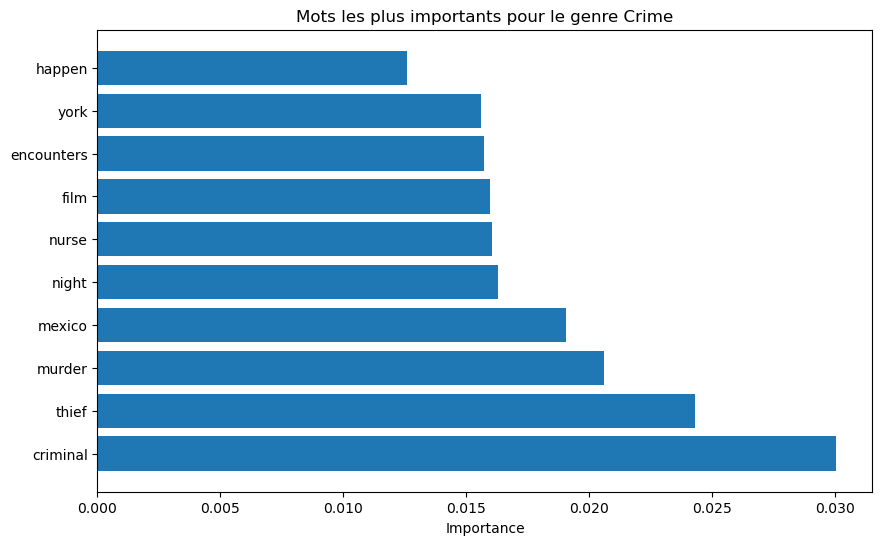

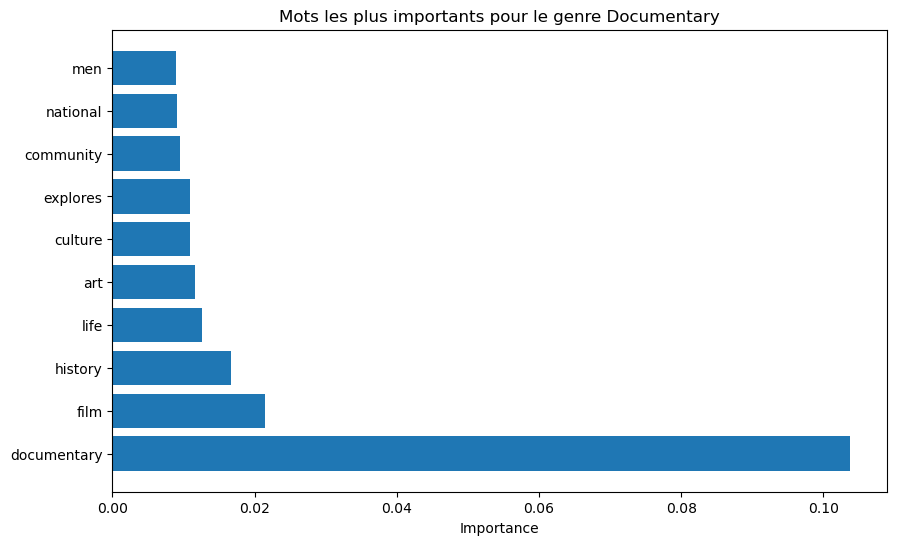

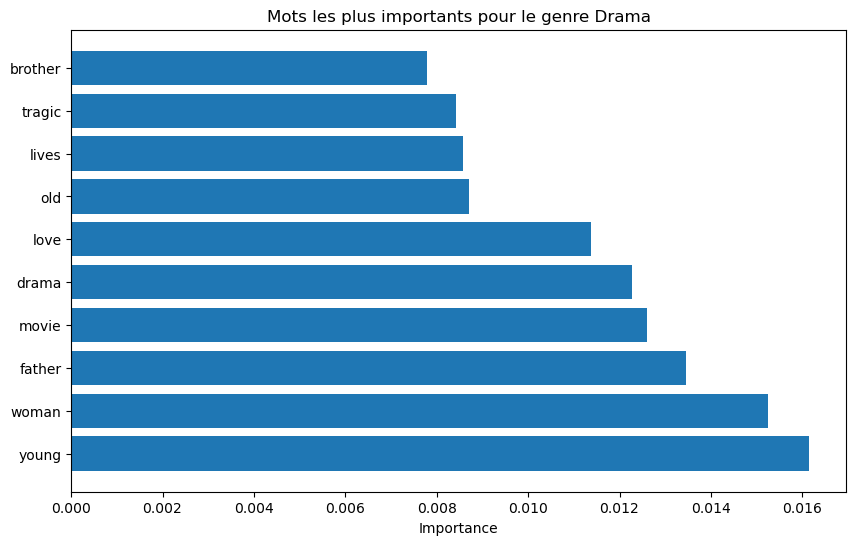

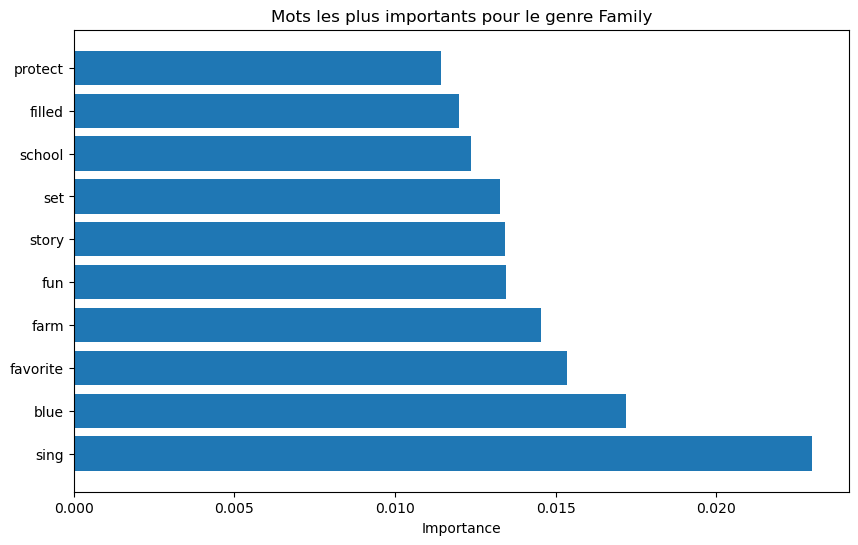

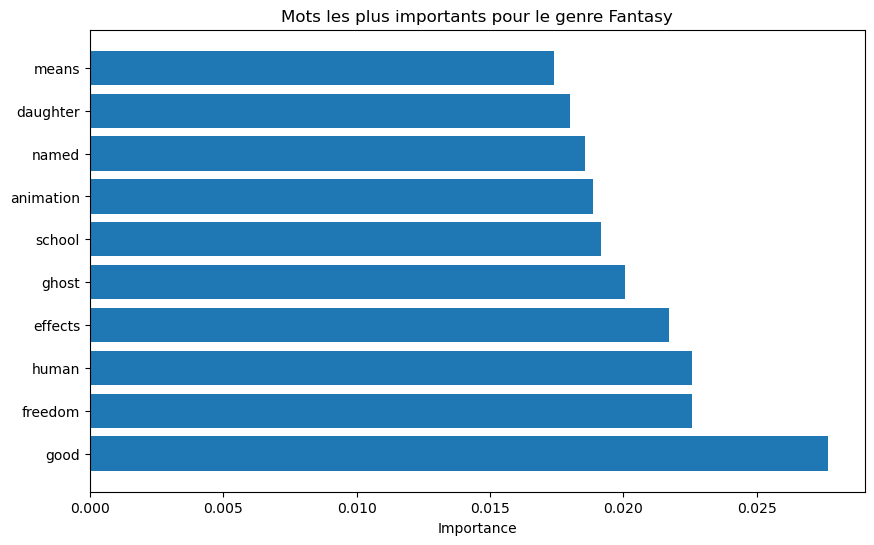

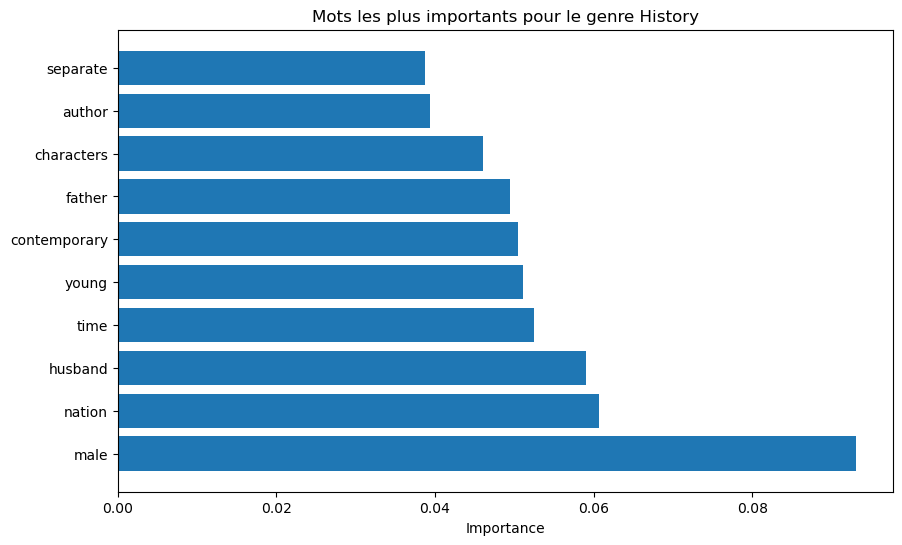

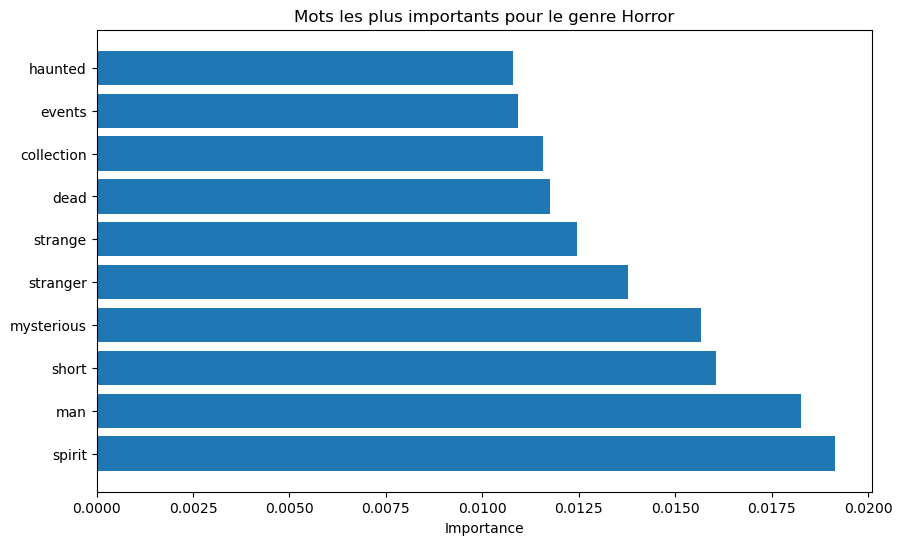

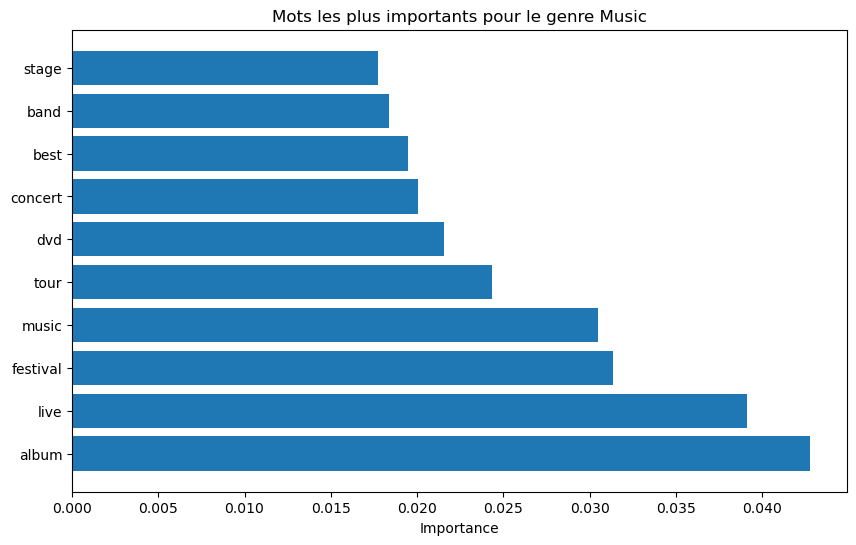

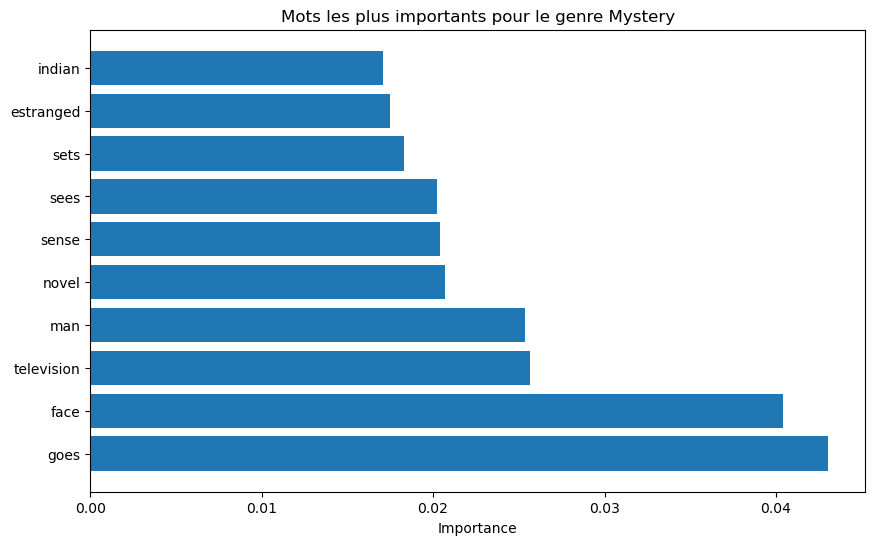

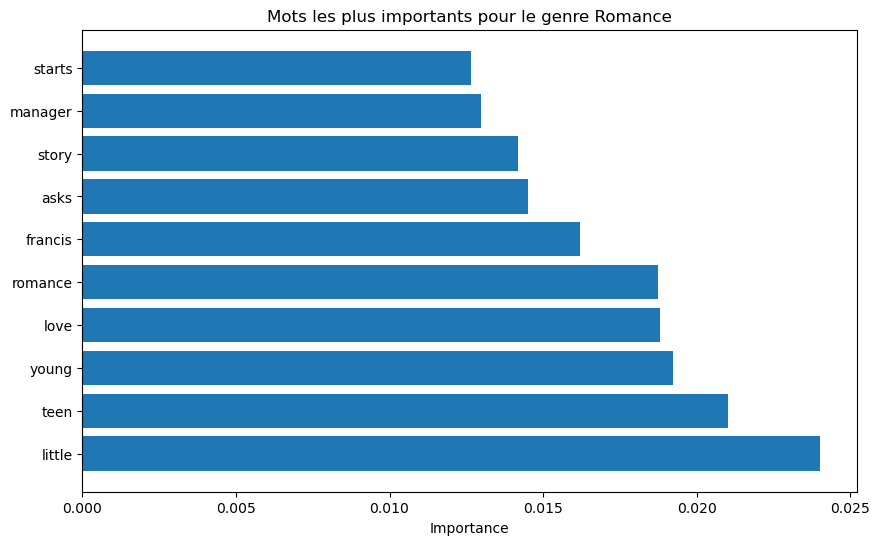

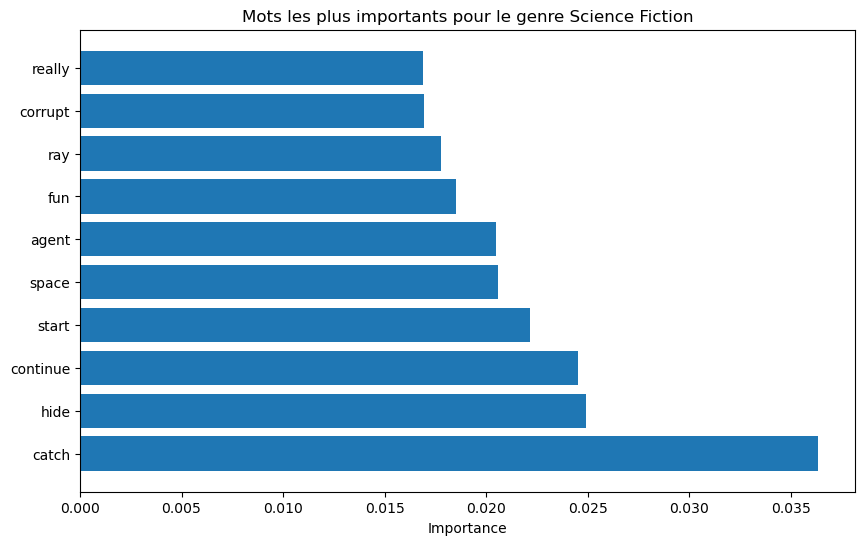

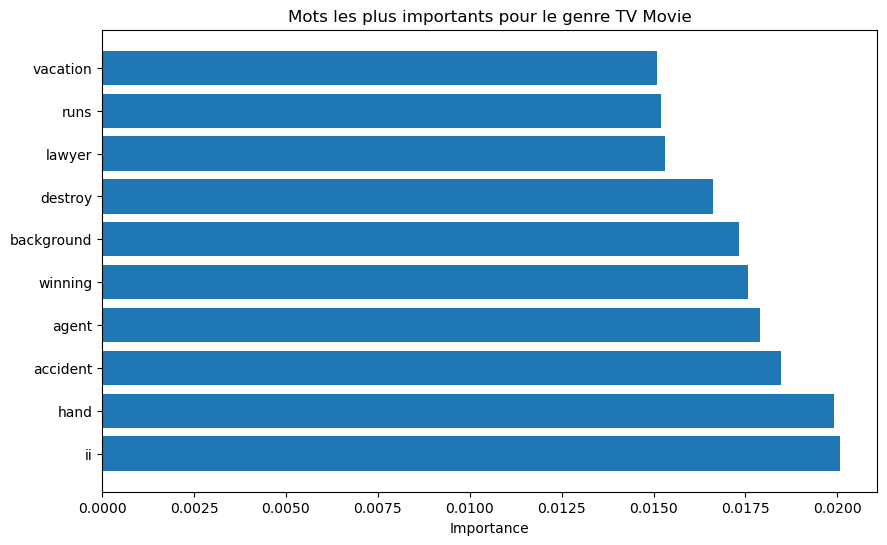

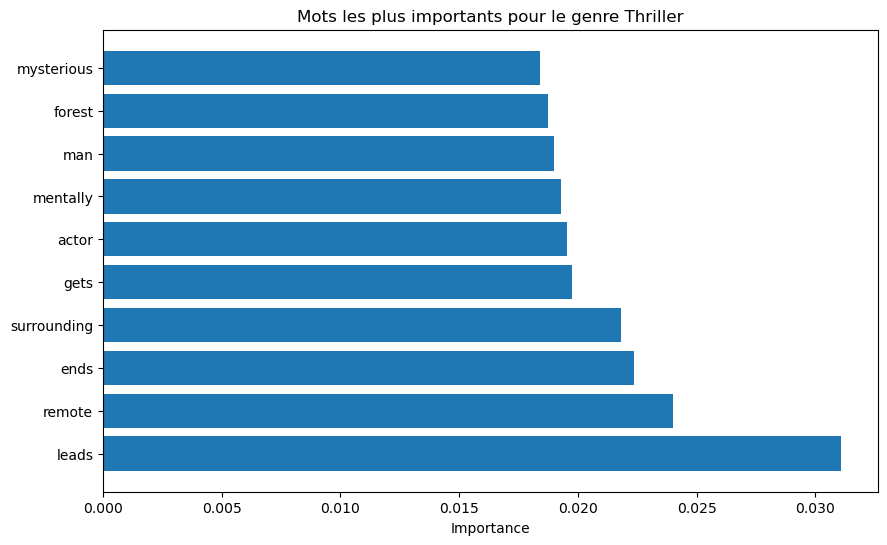

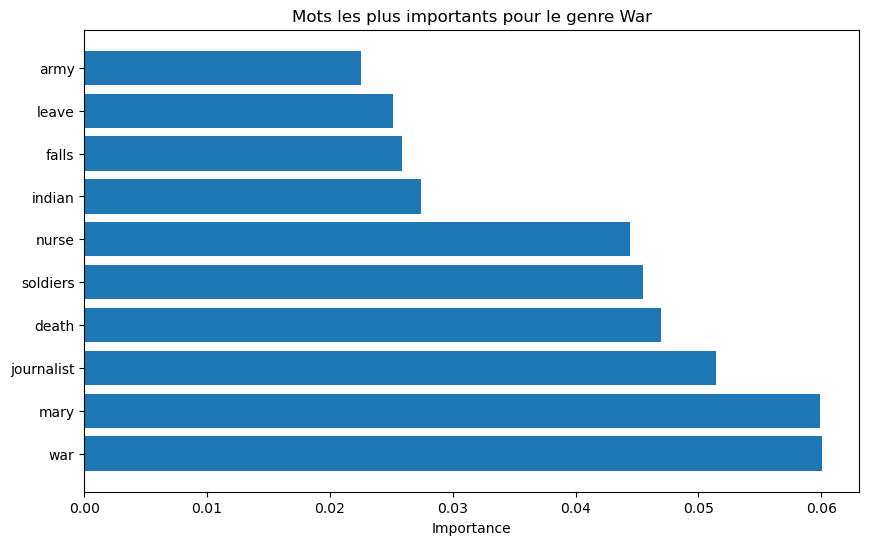

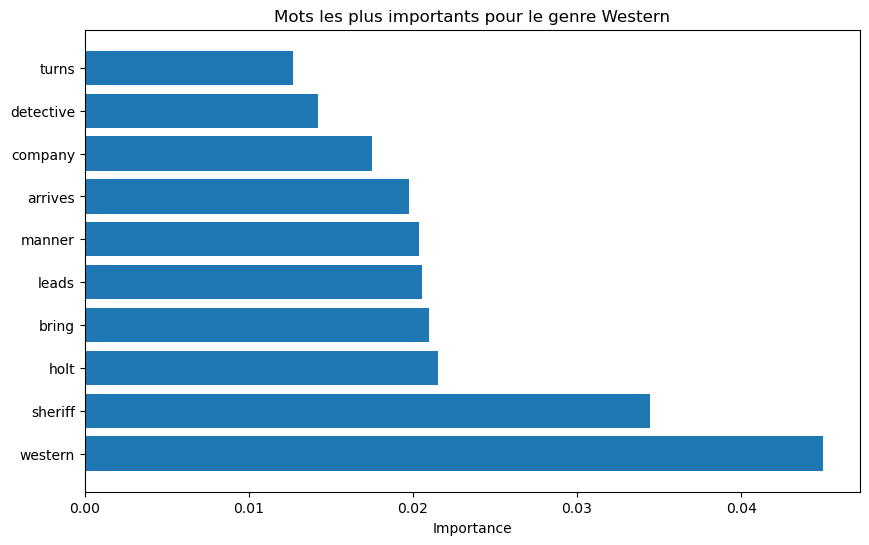

In [72]:
X = df1['overview']
y = df1['main_genre_name']

rf_nlp_full, vectorizer_full, label_encoder_full=gp.rfnlp(X,y, random_state=3)

for i in range(len(rf_nlp_full.estimators_)):
    gp.plot_important_words_for_genre(rf_nlp_full.estimators_[i].feature_importances_, 
                                vectorizer_full.get_feature_names_out(), i, label_encoder_full)

In [34]:
X = df1['overview']
y = df1['main_genre_name']

model, vectorizer, label_encoder_full=gp.rftest(X,y, random_state=3)


Rapport de classification :
                 precision    recall  f1-score   support

         Action       0.40      0.10      0.16        20
      Adventure       0.00      0.00      0.00         6
      Animation       0.50      0.21      0.30        28
         Comedy       0.36      0.39      0.38        61
          Crime       0.00      0.00      0.00         7
    Documentary       0.41      0.66      0.51        77
          Drama       0.43      0.68      0.53       102
         Family       0.00      0.00      0.00         2
        Fantasy       0.00      0.00      0.00         2
        History       0.00      0.00      0.00         3
         Horror       0.00      0.00      0.00        18
          Music       0.25      0.10      0.14        10
        Mystery       0.00      0.00      0.00         2
        Romance       0.00      0.00      0.00        18
Science Fiction       0.00      0.00      0.00         5
       TV Movie       0.00      0.00      0.00         5
 

/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Rapport de classification :
              precision    recall  f1-score   support

      Comedy       0.52      0.54      0.53        52
       Drama       0.76      0.75      0.75       102

    accuracy                           0.68       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.68      0.68      0.68       154



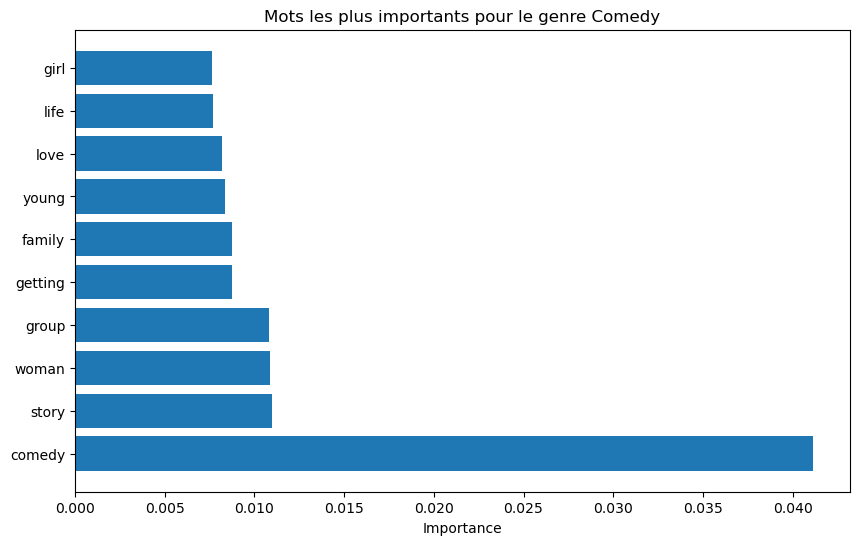

In [ ]:
df1cda=df1[df1['main_genre_id'].isin([18, 35])]

X=df1cda['overview']
y=df1cda['main_genre_name']

rf_nlp_cda, vectorizer_cda, label_encoder_cda=gp.rfnlp(X,y, random_state=1)
#for i in range(len(rf_nlp_cda.estimators_)):
#    gp.plot_important_words_for_genre(rf_nlp_cda.estimators_[i].feature_importances_, 
#                                vectorizer_cda.get_feature_names_out(), i, label_encoder_cda)

In [50]:
df1cda=df1[df1['main_genre_id'].isin([18, 35])]

X=df1cda['overview']
y=df1cda['main_genre_name']

rf_nlp_cda, vectorizer_cda, label_encoder_cda=gp.rftest(X,y, random_state=1)


Rapport de classification :
              precision    recall  f1-score   support

      Comedy       0.52      0.54      0.53        52
       Drama       0.76      0.75      0.75       102

    accuracy                           0.68       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.68      0.68      0.68       154



In [78]:
df2=df1[df1['main_genre_id'].isin([18, 35])]

# Séparation des caractéristiques (X) et des labels (y)
X = df2.drop(columns=['id','release_date', 'title', 'main_genre_name', "full_poster_path"])
num=X.drop(columns=["overview"]).columns
y = df2['main_genre_id']

# Séparation en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Prétraitement pour les colonnes textuelles et numériques
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(), 'overview'),                 # Transformation TF-IDF pour les données textuelles
        ('num', StandardScaler(), num)  # Normalisation des données numériques
    ]
)

# Pipeline complet
pipeline = Pipeline([
    ('preprocessor', preprocessor),  # Étape de prétraitement
    ('classifier', RandomForestClassifier(random_state=1))  # Modèle RFC
])

# Entraîner le modèle
pipeline.fit(X_train, y_train)

# Prédictions et évaluation
y_pred = pipeline.predict(X_test)
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))



Rapport de classification :
              precision    recall  f1-score   support

          18       0.90      1.00      0.95       107
          35       1.00      0.74      0.85        47

    accuracy                           0.92       154
   macro avg       0.95      0.87      0.90       154
weighted avg       0.93      0.92      0.92       154



Dimensions des données avant PCA : (766, 7)
Dimensions des données après PCA : (766, 2)
components:	[[ 0.59764596  0.38819593  0.39205705  0.52040686  0.18141114  0.02396366
   0.18468063]
 [ 0.34508418 -0.43573353 -0.37999128  0.48380948 -0.43480259 -0.1684133
  -0.30849938]]
variance expliquée par les 2 premières composantes:	[0.2879868 0.1887116]


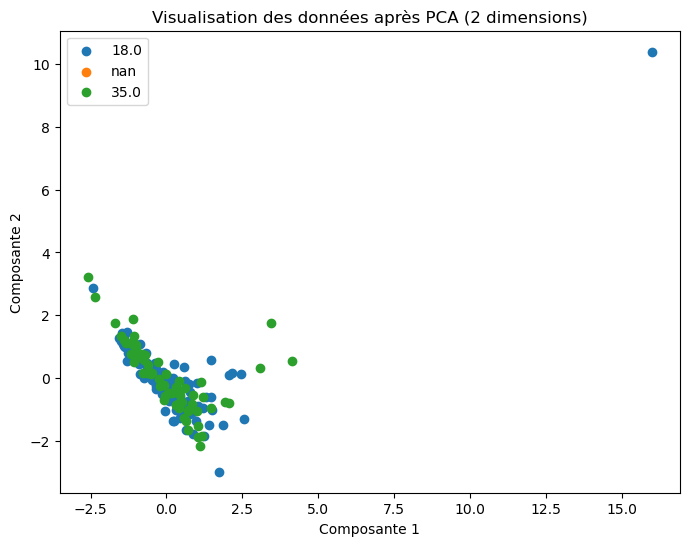

,Composante 1,Composante 2,classe
0,1.312684,-0.617868,18.0
1,0.362892,-0.940660,NaN
2,0.267163,-0.144945,NaN
3,-1.078039,0.884319,NaN
4,0.175534,-1.616509,NaN


In [56]:
from sklearn.decomposition import PCA

dfrf=df1[df1['main_genre_id'].isin([ 18,35])]

X=dfrf.drop(columns=['id','overview','release_date', 'title', 'main_genre_name', "full_poster_path", "revenue","budget",'main_genre_id'])
y=dfrf['main_genre_id']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# Convertir le résultat en DataFrame
X = pd.DataFrame(scaled_data, columns=X.columns)

print('Dimensions des données avant PCA : {}'.format(X.shape))

n_components = 2
pca = PCA(n_components=n_components)  # n_components entre 2 et le nombre de features (ici 5) 
x_2d = pca.fit_transform(X)
print('Dimensions des données après PCA : {}'.format(x_2d.shape))
print('components:\t{}'.format(pca.components_))
print('variance expliquée par les {} premières composantes:\t{}'.format(n_components, pca.explained_variance_ratio_))

# # ==> 99.9% de la variance associée au jeu de données est représenté par al 1ère composante 

# # Création d'un dataframe avec les données transformées:
columns=['Composante {}'.format(i) for i in range(1, n_components + 1)]
df_pca = pd.DataFrame(x_2d, columns=columns)
df_pca['classe'] = y


# # Visualiser les données PCA en 2D
plt.figure(figsize=(8, 6))
for classe in df_pca['classe'].unique():
    subset = df_pca[df_pca['classe'] == classe]
    plt.scatter(subset['Composante 1'], subset['Composante 2'], label=classe)

plt.title("Visualisation des données après PCA (2 dimensions)")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.legend()
plt.show()
df_pca.head()